In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_tips = sns.load_dataset('tips')
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df_tips.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


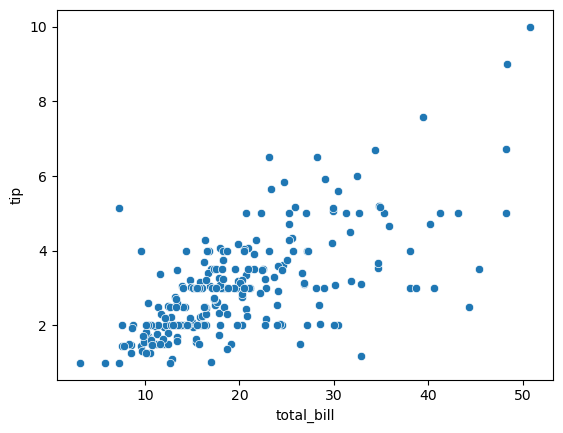

In [5]:
## Melihat korelasi antara Total bill dan Tip
sns.scatterplot(data = df_tips, x='total_bill', y='tip')
plt.show()

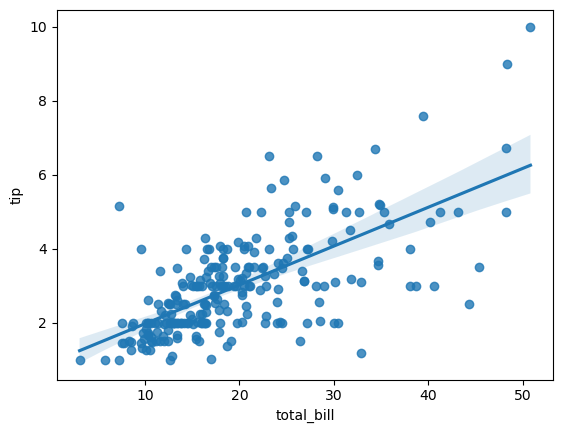

In [6]:
sns.regplot(data=df_tips, x = 'total_bill', y='tip');
## Hubungannya - Korelasi Linear Positif
## Semakin tinggi nilai total_bill, maka semakin tinggi nilai tip nya

In [7]:
df_tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


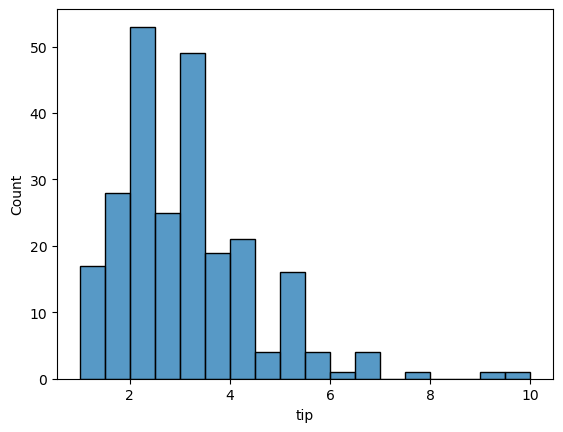

In [8]:
sns.histplot(data=df_tips, x ='tip');

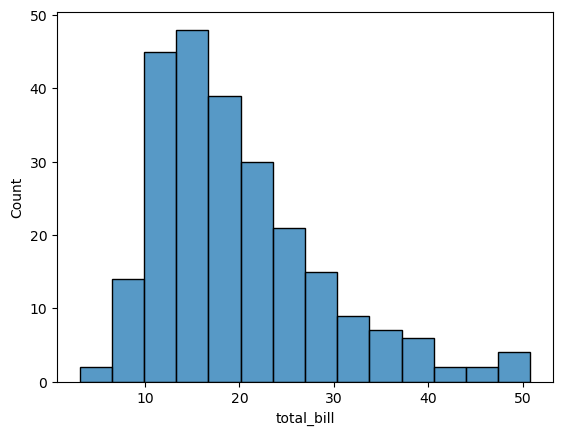

In [9]:
sns.histplot(data=df_tips, x ='total_bill');

In [10]:
df_tips['total_bill'].corr(df_tips['tip'], method='pearson')

0.6757341092113646

In [11]:
df_tips['total_bill'].corr(df_tips['tip'], method='spearman')

0.6789681219001009

## Membuat Model Linear Regression menggunakan Model Stats

In [12]:
import statsmodels.api as sm

In [13]:
### Menentukan Features & Target
X = df_tips[['total_bill']] ## Features
y = df_tips['tip'] ## target

In [14]:
X = sm.add_constant(X)
X.head()

,const,total_bill
0,1.0,16.99
1,1.0,10.34
2,1.0,21.01
3,1.0,23.68
4,1.0,24.59


In [15]:
## Modelling

OLS ==> Ordinary Least Square

In [16]:
Model = sm.OLS(y, X)

In [17]:
model_result = Model.fit()

In [19]:
print(model_result.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 11 Jul 2024   Prob (F-statistic):           6.69e-34
Time:                        20:01:16   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

## Output yg harus dibaca dan Perlu diperhatikan
1. Prob (F-statistic) ==> nilai p-value untuk uji F test
2. P>|t| ==> Nilai p-value untuk uji T test
3. coef
4. R-squared

In [20]:
## MEngambil nilai Koefisien
model_result.params

const         0.920270
total_bill    0.105025
dtype: float64

In [22]:
## P value untuk F-Test
model_result.f_pvalue

6.692470646863209e-34

In [24]:
##PValue untuk T test
model_result.pvalues

const         2.526443e-08
total_bill    6.692471e-34
dtype: float64

## Model Interpretation

y = a*x + b
y = 0.105025 * x + 0.920270

1. Prob F-Statistic

- H0 : B1 = 0 --> Total Bill Tidak berpengaruh signifikan terhadap nilai tip
- Ha : B1 != 0 --> total bill berpengaruh signifikan terhadap nilai Tip
- Prob F-Statistic ==> 6.69e-34
- nilai pvalue < 0.05 --> Reject H0
- Artinya total_bill berpengaruh signifikan terhadap nilai tip

2. T test
- B0 : Intercept
    - Ho : B0 = 0 ---> Model tidak membutuhkan Intercept
    - Ha : B0 != b0 --> Model membutuhkan Intercept
    - P_value : 2.526443e-08
    - nilai pvalue < 0.05 --> Reject Ho
    - Artinya model membutuhkan Intercept
- B1 : Slope - Total_Bill
    - Ho : B1 = 0 --> Total_bill tidak berpengaruh signifikan terhadap nilai tip
    - Ha : B1 != 0 --> Total_bill berpengaruh signifikan terhadap nilai tip
    - P_value : 6.692471e-34
    - nilai pvalue < 0.05 --> Reject H0
    - Artinya total bill berpengaruh signifikan terhadap nilai Tip
3. Coef
y = 0.105025 * x + 0.920270
- B0 : 0.920270
    - Ketika nilai total bill (X) sama dengan 0, maka nilai tip nya(y) adalah 0.920270 dollar (Menurut nodel ini Make sense, meskipun menurut kita ini tidak masuk akal (sesuai Konteks makan di restoran) tetapi Make sense untuk model (Model tidak tau Konteks, ==> menurunkan Error sekecil mungkin
- B1 : 0.105025
    - Ketika total bill (X) naik 1 dollar maka tip nya naik 0.105025 dan berlaku kelipatan
4. R-squared:                       0.457
- Artinya Model ini (dengan features Total bill) dapat menjelaskan 45.7% variance-informasi dari nilai tip. Sisanya 54.3% dapat dijelaskan dg Features lain yg tidak ada di Model ini

In [28]:
df_tips.describe()[['total_bill']].loc[['min', 'max']]

,total_bill
min,3.07
max,50.81


## Predict

In [29]:
model_result.predict(X)

0      2.704636
1      2.006223
2      3.126835
3      3.407250
4      3.502822
         ...   
239    3.969131
240    3.774836
241    3.301175
242    2.791807
243    2.892630
Length: 244, dtype: float64

In [30]:
df_result = df_tips[['total_bill', 'tip']]
df_result.head()

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [31]:
df_result.rename(columns={'tip' : 'y_actual'}, inplace=True)


In [32]:
df_result['y_pred'] = model_result.predict(X)

In [33]:
df_result.head()

,total_bill,y_actual,y_pred
0,16.99,1.01,2.704636
1,10.34,1.66,2.006223
2,21.01,3.50,3.126835
3,23.68,3.31,3.407250
4,24.59,3.61,3.502822


## Evaluation Metrics

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [35]:
mean_absolute_error(df_result['y_actual'], df_result['y_pred'])

0.7458253894586341

## MAE (Mean Squared Error)

In [36]:
MAE = abs(df_result['y_actual'] - df_result['y_pred']).mean()
MAE

0.7458253894586341

## MSE (Mean Squared Error)

In [38]:
MSE = ((df_result['y_actual'] - df_result['y_pred'])**2).mean()
MSE

1.036019442011377

In [41]:
np.power((df_result['y_actual'] - df_result['y_pred']),2).mean()

1.036019442011377

## RMSE (Root Mean Squared Error)

In [42]:
RMSE = np.sqrt(MSE)
RMSE

1.0178504025697377

## Predict New Data

In [43]:
X.head()

,const,total_bill
0,1.0,16.99
1,1.0,10.34
2,1.0,21.01
3,1.0,23.68
4,1.0,24.59


In [44]:
new_data = pd.DataFrame(
{'const' : [1],
 'total_bill' : [25.95]
})
new_data

,const,total_bill
0,1,25.95


In [47]:
model_result.predict(new_data).round(2)

0    3.65
dtype: float64

In [49]:
tip_predict = (0.105025 * 25.95) + (0.920270 * 1)
round(tip_predict, 2)

3.65

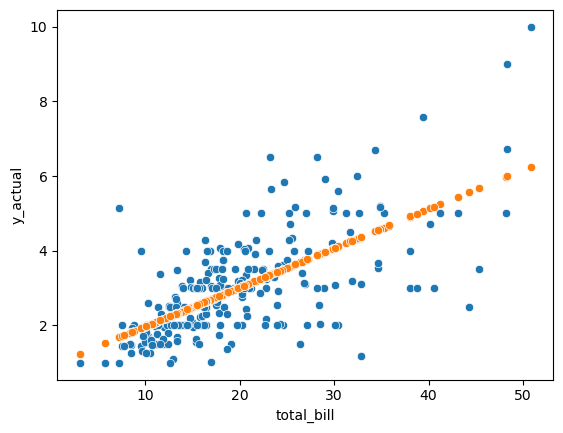

In [51]:
sns.scatterplot(data=df_result, x='total_bill', y='y_actual')
sns.scatterplot(data=df_result, x='total_bill', y='y_pred')
plt.show()